# Notebook 5 – Logistic Regression


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Classification

Classification predicts a category, not a number. `IsCancelled` (Yes/No)
is our running example of a classification target.

## Binary Classification

The specific case where there are exactly two possible categories. Our
`IsCancelled` target (0 = not cancelled, 1 = cancelled) is binary.

## Why Logistic Regression Is a Classification Algorithm, Despite Its Name

The name is genuinely confusing, and worth addressing directly before
anything else. "Regression" in the name refers to *how it works
internally*, not to what it predicts. Logistic Regression fits a linear
combination of inputs (like Linear Regression does), but then passes that
linear result through the **sigmoid function**, which squashes it into a
probability between 0 and 1. That probability is then converted into a
class label using a threshold. So internally it's doing a regression-like
calculation on a continuous score, but the final output, and the entire
purpose of using it, is a category (0 or 1), which makes it a
classification algorithm in practice, despite the "regression" in its
name.

## Logistic Regression

**What it does:** models the *probability* that an observation belongs
to a class, using a linear combination of the inputs, transformed by the
sigmoid function.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols].fillna(0)
y = df["IsCancelled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Sigmoid Function

**What it does:** maps any real number (from negative infinity to
positive infinity) into a value strictly between 0 and 1. Formula:

`sigmoid(z) = 1 / (1 + e^(-z))`

Where `z` is the linear combination of inputs and coefficients
(`z = b0 + b1*x1 + b2*x2 + ...`), exactly like the equation of a line
from the Linear Regression notebook, just passed through this extra
squashing step.

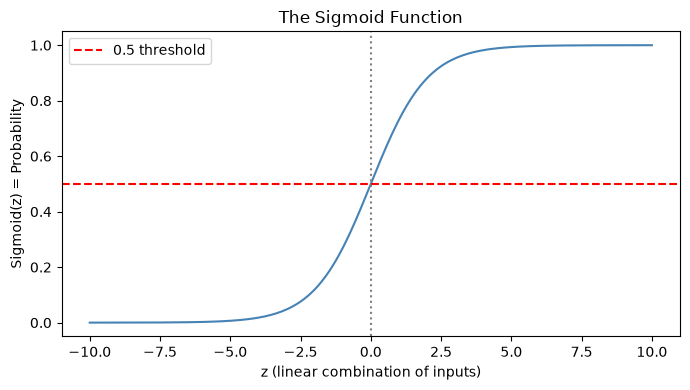

In [3]:
import matplotlib.pyplot as plt

z_values = np.linspace(-10, 10, 200)
sigmoid_values = 1 / (1 + np.exp(-z_values))

plt.figure(figsize=(7, 4))
plt.plot(z_values, sigmoid_values, color="steelblue")
plt.axhline(y=0.5, color="red", linestyle="--", label="0.5 threshold")
plt.axvline(x=0, color="gray", linestyle=":")
plt.xlabel("z (linear combination of inputs)")
plt.ylabel("Sigmoid(z) = Probability")
plt.title("The Sigmoid Function")
plt.legend()
plt.tight_layout()
plt.show()

## Probability

Logistic Regression's raw output is a probability, e.g., "this
transaction has a 73% chance of being cancelled," not a hard yes/no. We
access it with `.predict_proba()`, distinct from `.predict()` which
already applies a threshold.

In [4]:
probabilities = log_model.predict_proba(X_test)[:, 1]
print("Sample predicted probabilities of cancellation:")
print(probabilities[:10].round(3))

Sample predicted probabilities of cancellation:
[0.447 0.452 0.451 0.473 0.446 0.464 0.458 0.46  0.496 0.501]


## Decision Boundary and Threshold

**Threshold:** the probability cutoff used to convert a probability into
a class label. The default is 0.5, probability >= 0.5 becomes class 1,
below becomes class 0.

**Decision boundary:** the set of points where the model is exactly
undecided (probability = 0.5), it's the boundary separating the two
predicted classes in feature space. Changing the threshold moves this
boundary and changes the trade-off between false positives and false
negatives.

In [5]:
from sklearn.metrics import classification_report

default_predictions = (probabilities >= 0.5).astype(int)
print("Threshold = 0.5:")
print(classification_report(y_test, default_predictions, zero_division=0))

lower_threshold_predictions = (probabilities >= 0.3).astype(int)
print("\nThreshold = 0.3 (catches more cancellations, at the cost of more false alarms):")
print(classification_report(y_test, lower_threshold_predictions, zero_division=0))

Threshold = 0.5:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90    106233
           1       0.03      0.31      0.05      1858

    accuracy                           0.82    108091
   macro avg       0.51      0.57      0.48    108091
weighted avg       0.97      0.82      0.88    108091


Threshold = 0.3 (catches more cancellations, at the cost of more false alarms):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    106233
           1       0.02      1.00      0.03      1858

    accuracy                           0.02    108091
   macro avg       0.01      0.50      0.02    108091
weighted avg       0.00      0.02      0.00    108091



Lowering the threshold from 0.5 to 0.3 changes recall and precision for
the cancelled class, exactly what "moving the decision boundary" means in
practice, we're not retraining the model, just changing where we draw the
line on its existing probability outputs.

## Log Loss

**What it is:** the cost function Logistic Regression minimizes during
training (its equivalent of Linear Regression's Mean Squared Error).
It penalizes confident wrong predictions much more heavily than
uncertain wrong ones, a model that says "99% cancelled" for a transaction
that wasn't cancelled gets penalized far more than one that said "55%
cancelled."

Formula: `-mean( y*log(p) + (1-y)*log(1-p) )`

In [6]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, probabilities)
print("Log Loss on test set:", round(loss, 4))

# Illustrating the "confident wrong prediction" penalty directly
print("\nLog loss if truly cancelled but predicted 0.01 probability (very wrong, very confident):", round(log_loss([1], [0.01], labels=[0,1]), 4))
print("Log loss if truly cancelled but predicted 0.45 probability (wrong, but uncertain):", round(log_loss([1], [0.45], labels=[0,1]), 4))

Log Loss on test set: 0.6751

Log loss if truly cancelled but predicted 0.01 probability (very wrong, very confident): 4.6052
Log loss if truly cancelled but predicted 0.45 probability (wrong, but uncertain): 0.7985


## Coefficients

Just like Linear Regression, Logistic Regression learns one coefficient
per input feature, but here they describe how each feature affects the
*log-odds* of the outcome, not the raw outcome directly. A positive
coefficient means increasing that feature increases the probability of
the positive class (cancellation); negative means it decreases it.

In [7]:
for feature, coef in zip(feature_cols, log_model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print("Intercept:", round(log_model.intercept_[0], 4))

AbsQuantity: 0.0004
UnitPrice: 0.0158
Month: -0.0218
IsInternational: 0.6836
Intercept: -0.0131


## Multiclass Classification

**What it is:** classification with more than two possible categories.
Logistic Regression extends to this case (often called "multinomial
logistic regression"), predicting a probability for each class instead
of just one.

**Our example:** grouping customers into three spend tiers (Low, Medium,
High) based on `TotalSpend`, then predicting that tier using *other*
customer behavior, `NumOrders`, `AvgUnitPrice`, and `NumUniqueProducts`,
deliberately not `TotalSpend` itself, since that would trivially define
the tiers.

In [8]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("Revenue", "sum"),
    NumOrders=("InvoiceNo", "nunique"),
    AvgUnitPrice=("UnitPrice", "mean"),
    NumUniqueProducts=("StockCode", "nunique")
).reset_index()

customer_df = customer_df[customer_df["TotalSpend"] > 0]

q1, q2 = customer_df["TotalSpend"].quantile([0.33, 0.66])
customer_df["SpendTier"] = pd.cut(
    customer_df["TotalSpend"], bins=[-1, q1, q2, 1e9], labels=["Low", "Medium", "High"]
)
print(customer_df["SpendTier"].value_counts())

SpendTier
High      1470
Low       1427
Medium    1425
Name: count, dtype: int64


In [9]:
multi_features = ["NumOrders", "AvgUnitPrice", "NumUniqueProducts"]
X_multi = customer_df[multi_features]
y_multi = customer_df["SpendTier"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

# Current scikit-learn versions handle multiclass (multinomial) automatically,
# no need to specify multi_class="multinomial" manually anymore
multi_log_model = LogisticRegression(max_iter=1000)
multi_log_model.fit(X_train_m, y_train_m)

multi_predictions = multi_log_model.predict(X_test_m)
print(classification_report(y_test_m, multi_predictions, zero_division=0))

              precision    recall  f1-score   support

        High       0.85      0.77      0.81       294
         Low       0.71      0.81      0.76       286
      Medium       0.59      0.57      0.58       285

    accuracy                           0.72       865
   macro avg       0.72      0.72      0.72       865
weighted avg       0.72      0.72      0.72       865



With three classes instead of two, `.predict_proba()` now returns three
probabilities per row (one per tier), and the model predicts whichever
class has the highest probability, the same sigmoid-based logic extended
across multiple classes at once (technically using the softmax function
for more than two classes).

In [10]:
multi_probabilities = multi_log_model.predict_proba(X_test_m)
print("Classes:", multi_log_model.classes_)
print("Sample probabilities per class (each row sums to 1.0):")
print(multi_probabilities[:5].round(3))

Classes: ['High' 'Low' 'Medium']
Sample probabilities per class (each row sums to 1.0):
[[0.069 0.542 0.389]
 [0.032 0.646 0.321]
 [0.292 0.081 0.626]
 [0.106 0.322 0.572]
 [1.    0.    0.   ]]
